# Exploratory data analysis - UV index research

In [1]:
import sys

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14,5)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path('../..') / 'data' / 'processed'
df = pd.read_csv(DATA_DIR / 'merged_hourly.csv', parse_dates=['timestamp'])
print(f'Shape: {df.shape}')
print(f"Date range: {df['timestamp'].min()} - {df['timestamp'].max()}")
print(f"Locations: {df['location_id'].unique().tolist()}")
df.head()


Shape: (792768, 74)
Date range: 2015-01-01 00:00:00+07:00 - 2026-04-21 23:00:00+07:00
Locations: ['cangio', 'thuduc', 'dalat', 'longhai', 'vungtau', 'cuchi', 'hcm', 'nhabe']


,timestamp,location_id,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,weather_code,cloud_cover,cloud_cover_low,...,solar_elevation,solar_azimuth,solar_zenith,cos_solar_zenith,heat_index,heat_stress_level,uv_source,uv_daily_max_openuv,is_day,location_type
0,2015-01-01 00:00:00+07:00,cangio,2015-01-01,23.4,80,25.6,0.0,3,97,2,...,10.519783,116.006298,79.480217,0.182575,23.884444,comfortable,none,NaN,1,coastal_ecosystem
1,2015-01-01 01:00:00+07:00,cangio,2015-01-01,23.3,81,25.7,0.0,3,95,16,...,23.458480,120.877743,66.541520,0.398084,23.800556,comfortable,none,NaN,1,coastal_ecosystem
2,2015-01-01 02:00:00+07:00,cangio,2015-01-01,23.4,81,26.1,0.0,2,70,9,...,35.612608,128.368825,54.387392,0.582302,23.910556,comfortable,none,NaN,1,coastal_ecosystem
3,2015-01-01 03:00:00+07:00,cangio,2015-01-01,23.2,83,26.1,0.0,1,49,16,...,46.238079,140.059231,43.761921,0.722220,23.742778,comfortable,none,NaN,1,coastal_ecosystem
4,2015-01-01 04:00:00+07:00,cangio,2015-01-01,22.8,85,25.8,0.0,2,51,22,...,53.922605,158.016594,36.077395,0.808222,23.355000,comfortable,none,NaN,1,coastal_ecosystem


# 1. Data overview

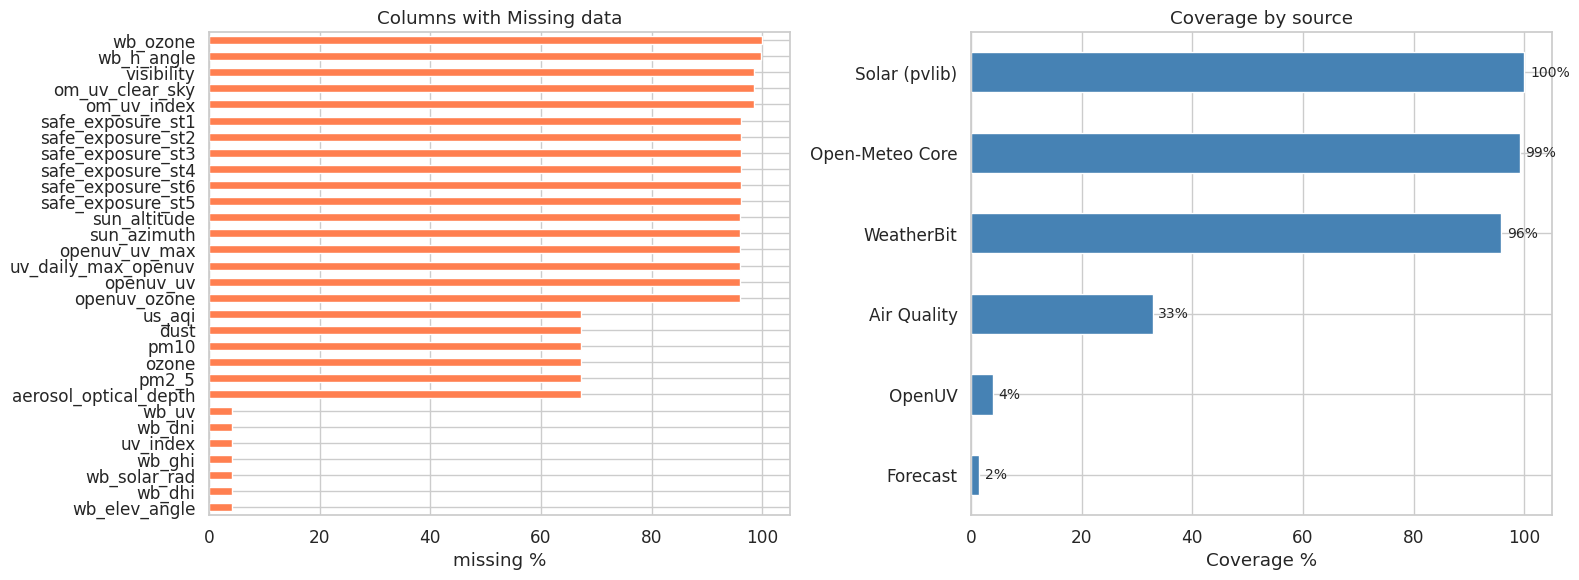

In [2]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing_nonzero = missing[missing > 0]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(missing_nonzero) > 0:
    missing_nonzero.plot.barh(ax=axes[0], color='coral')
    axes[0].set_xlabel('missing %')
    axes[0].set_title('Columns with Missing data')
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'No Missing values', ha='center', va='center')
    axes[0].set_title('Columns with Missing data')

groups = {
    'Open-Meteo Core': ['temperature_2m', 'cloud_cover', 'shortwave_radiation', 'uv_index', 'pressure_msl'],
    'Solar (pvlib)': ['solar_elevation', 'solar_zenith', 'cos_solar_zenith'],
    'Air Quality': ['ozone', 'pm2_5', 'aerosol_optical_depth'],
    'WeatherBit': ['wb_uv', 'wb_solar_rad', 'wb_ghi'],
    'OpenUV': ['openuv_uv', 'openuv_ozone', 'openuv_uv_max'],
    'Forecast': ['om_uv_index', 'om_uv_clear_sky', 'visibility']
}

coverage = {}
for name, cols in groups.items():
    existing = [c for c in cols if c in df.columns]
    if existing:
        coverage[name] = np.mean([df[c].notna().mean() for c in existing]) * 100
pd.Series(coverage).sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Coverage %')
axes[1].set_title('Coverage by source')
axes[1].set_xlim(0, 105)
for i, (name, val) in enumerate(sorted(coverage.items(), key=lambda x: x[1])):
    axes[1].text(val + 1, i, f'{val:.0f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

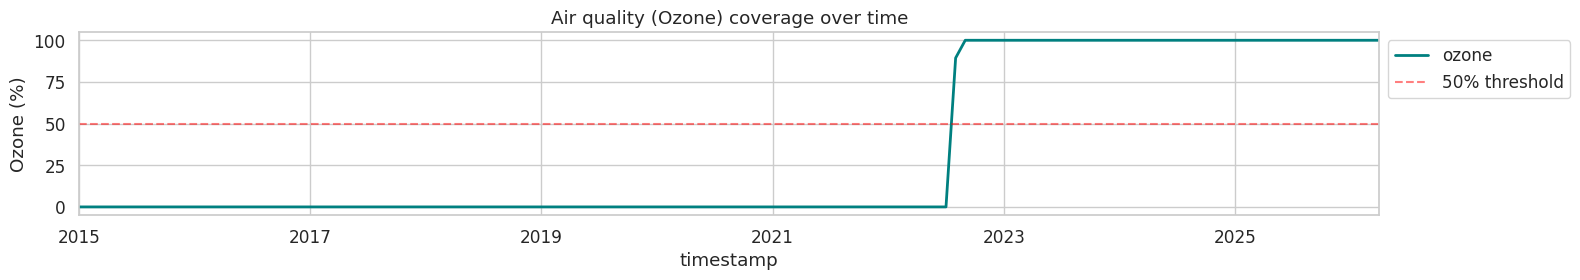

In [3]:
# 1.1
fig, ax = plt.subplots(figsize=(16, 3))
if 'ozone' in df.columns:
    monthly = df.set_index('timestamp').resample('ME')['ozone'].apply(lambda x: x.notna().mean() * 100)
    monthly.plot(ax=ax, color='teal', linewidth=2)
    ax.set_ylabel('Ozone (%)')
    ax.set_title('Air quality (Ozone) coverage over time')
    ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# 2 UV index distribution

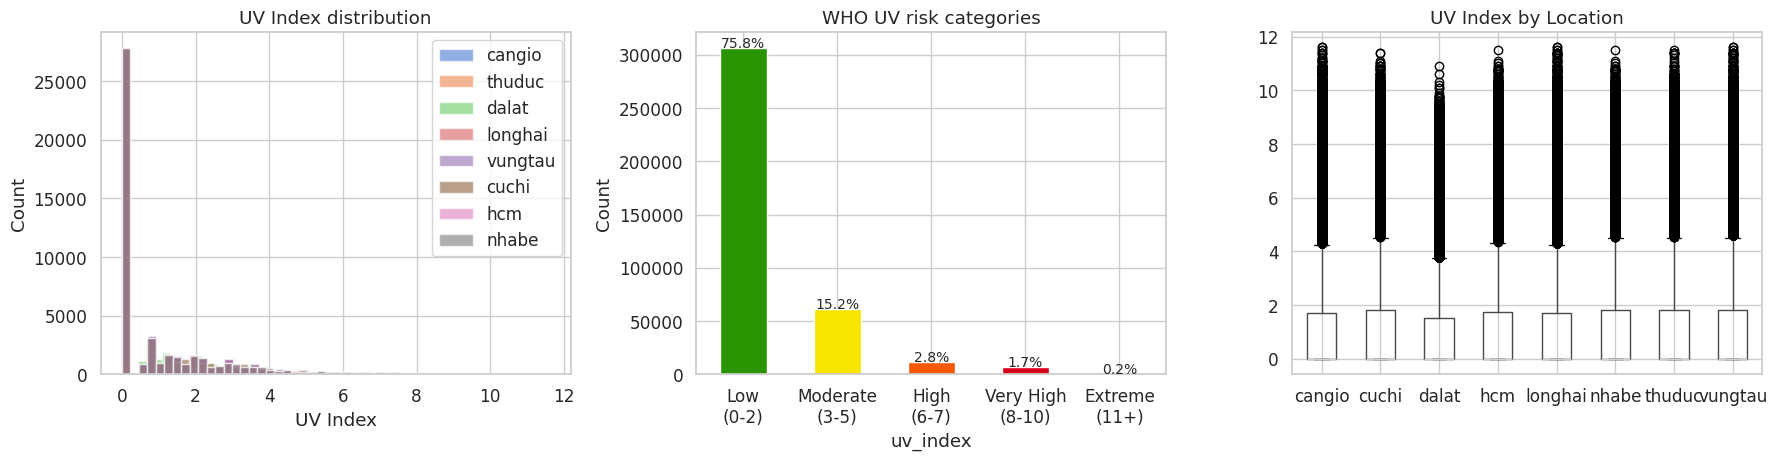

In [4]:

day = df[df['is_day'] == 1].copy()
day['hour'] = day['timestamp'].dt.hour
day['month'] = day['timestamp'].dt.month
day['year'] = day['timestamp'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for loc in day['location_id'].unique():
    sub = day[day['location_id'] == loc]
    axes[0].hist(sub['uv_index'], bins=50, alpha=0.6, label=loc, edgecolor='white')
axes[0].set_xlabel('UV Index')
axes[0].set_ylabel('Count')
axes[0].set_title('UV Index distribution')
axes[0].legend()

uv_cat = pd.cut(day['uv_index'], bins=[-0.1, 2,5,7,10, float('inf')],
                labels=['Low\n(0-2)', 'Moderate\n(3-5)', 'High\n(6-7)', 'Very High\n(8-10)', 'Extreme\n(11+)'])
colors = ['#289500', '#f7e400', '#f85900', '#d8001d', '#6b49c8']
counts = uv_cat.value_counts().sort_index()
counts.plot.bar(ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('WHO UV risk categories')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts):
    axes[1].text(i, v + 200, f'{v/len(day) * 100:.1f}%', ha='center', fontsize=10)

day.boxplot(column='uv_index', by='location_id', ax=axes[2])
axes[2].set_title('UV Index by Location')
axes[2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

# 3.UV Temporal Pattern

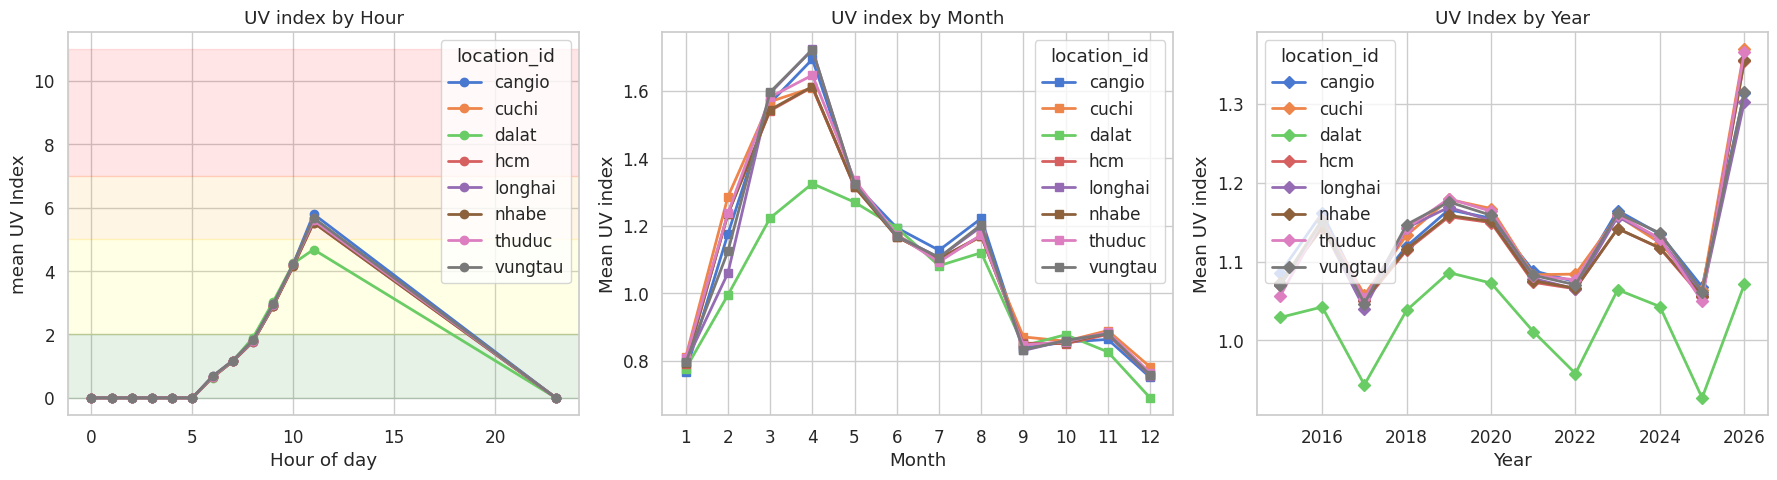

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly = day.groupby(['hour', 'location_id'])['uv_index'].mean().unstack()
hourly.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('mean UV Index')
axes[0].set_title('UV index by Hour')
axes[0].axhspan(0, 2, alpha=0.1, color='green', label='Low')
axes[0].axhspan(2, 5, alpha=0.1, color='yellow')
axes[0].axhspan(5, 7, alpha=0.1, color='orange')
axes[0].axhspan(7, 11, alpha=0.1, color='red')

monthly = day.groupby(['month', 'location_id'])['uv_index'].mean().unstack()
monthly.plot(ax=axes[1], marker='s', linewidth=2)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean UV index')
axes[1].set_title('UV index by Month')
axes[1].set_xticks(range(1, 13))

yearly = day.groupby(['year', 'location_id'])['uv_index'].mean().unstack()
yearly.plot(ax=axes[2], marker='D', linewidth=2)
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Mean UV index')
axes[2].set_title('UV Index by Year')

plt.tight_layout()
plt.show()

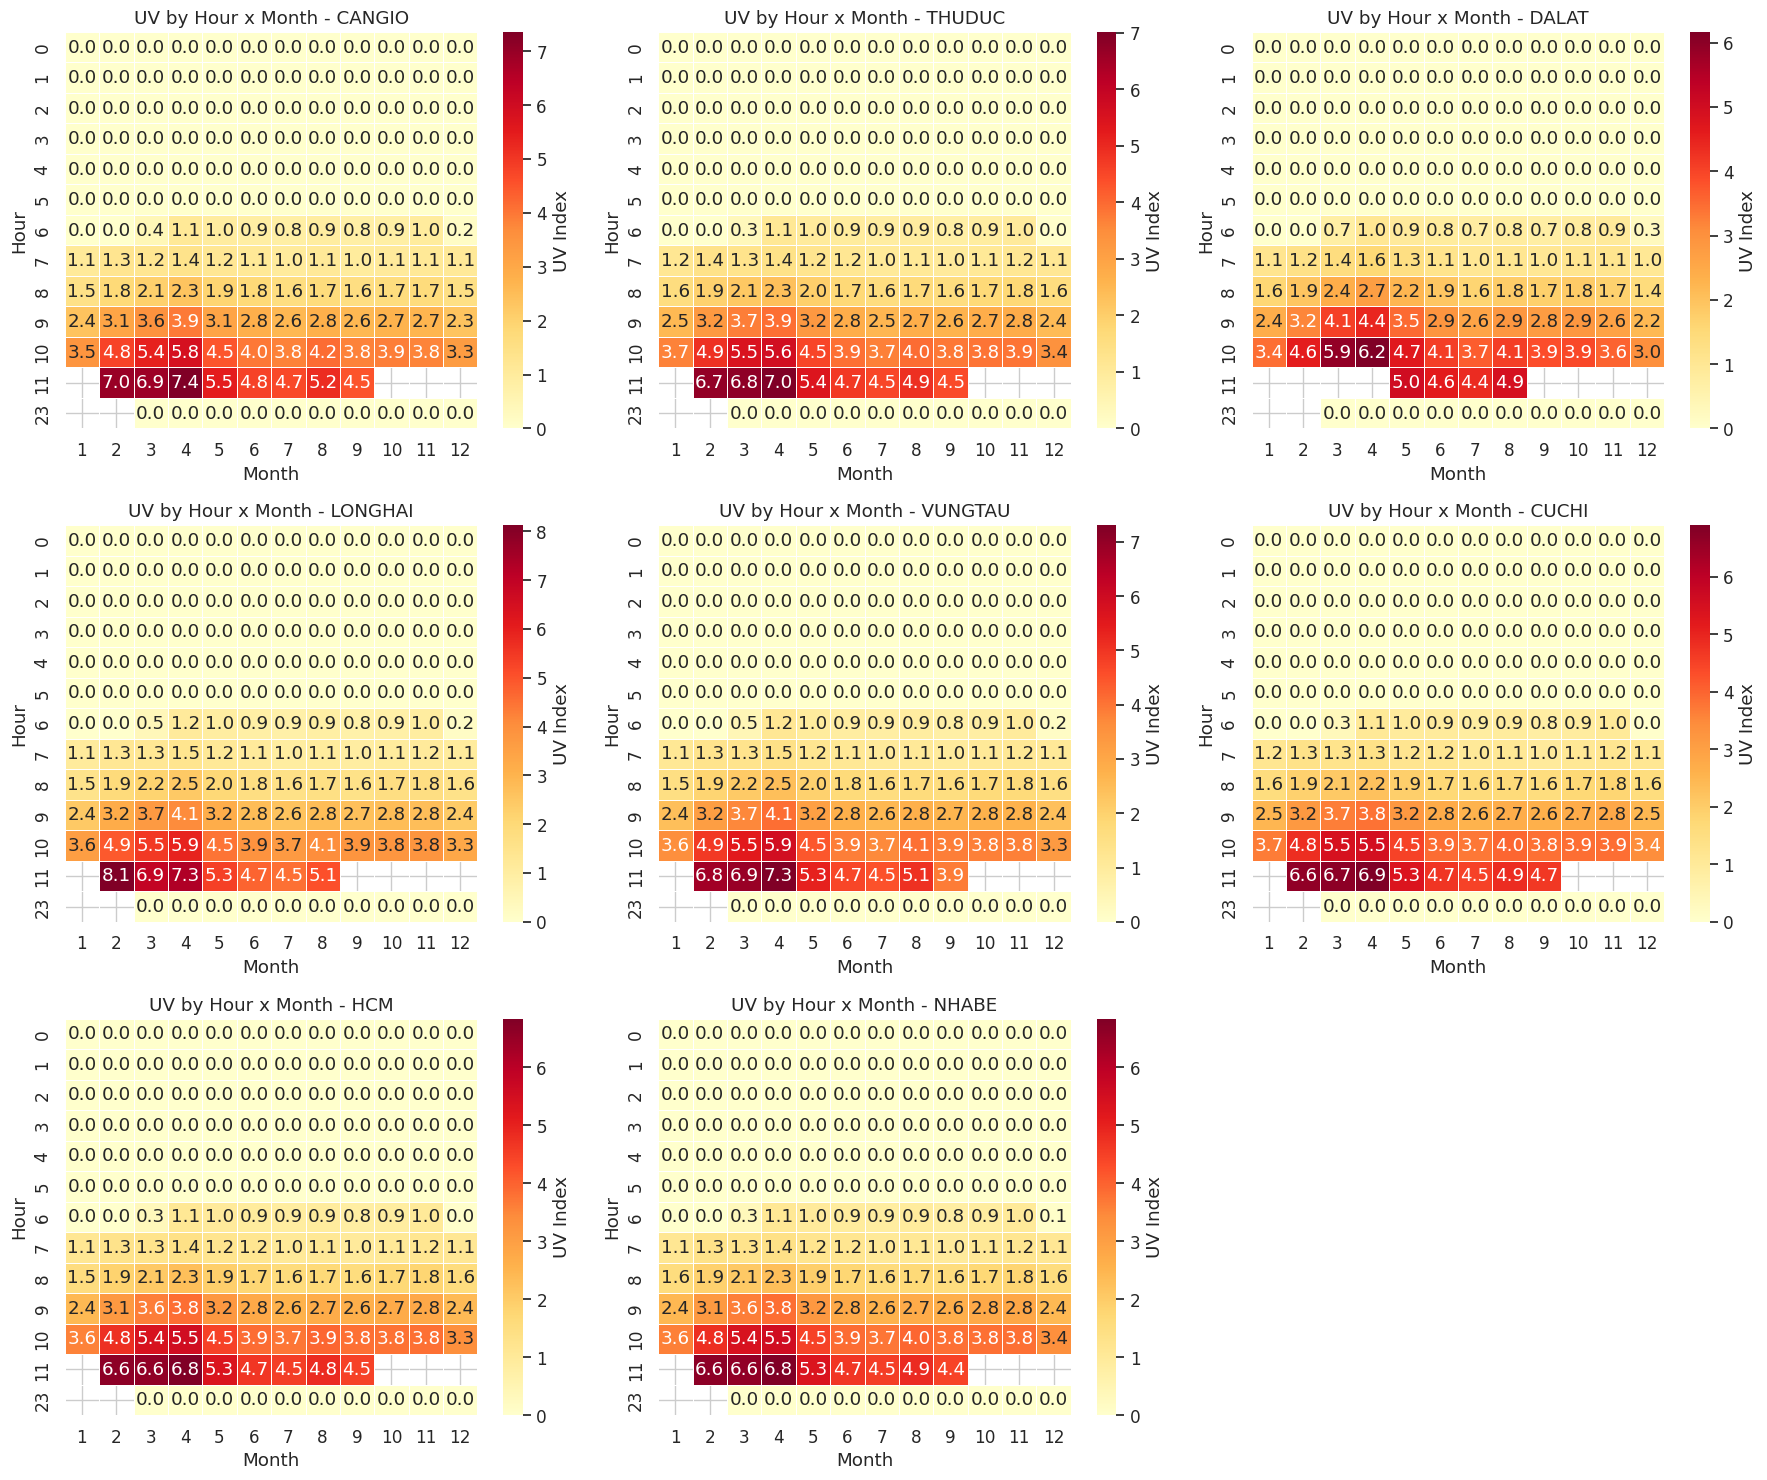

In [6]:
n_locs = len(day['location_id'].unique())
cols = 3
rows = int(np.ceil(n_locs / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
if rows * cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]
for i, loc in enumerate(day['location_id'].unique()):
    sub = day[day['location_id'] == loc]
    pivot = sub.pivot_table(values='uv_index', index='hour', columns='month', aggfunc='mean')
    sns.heatmap(pivot, ax=axes[i], cmap='YlOrRd', annot=True, fmt='.1f',
                cbar_kws={'label': 'UV Index'}, linewidths=.5)
    axes[i].set_title(f'UV by Hour x Month - {loc.upper()}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Hour')
for j in range(n_locs, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# 4. Feature Correlations

Available features: 11/20
Missing: {'humidity_change_1h', 'solar_cloud_interaction', 'hour_cos', 'pressure_change_3h', 'doy_sin', 'cloud_cover_change_1h', 'solar_noon_proximity', 'temp_change_3h', 'ozone_anomaly'}


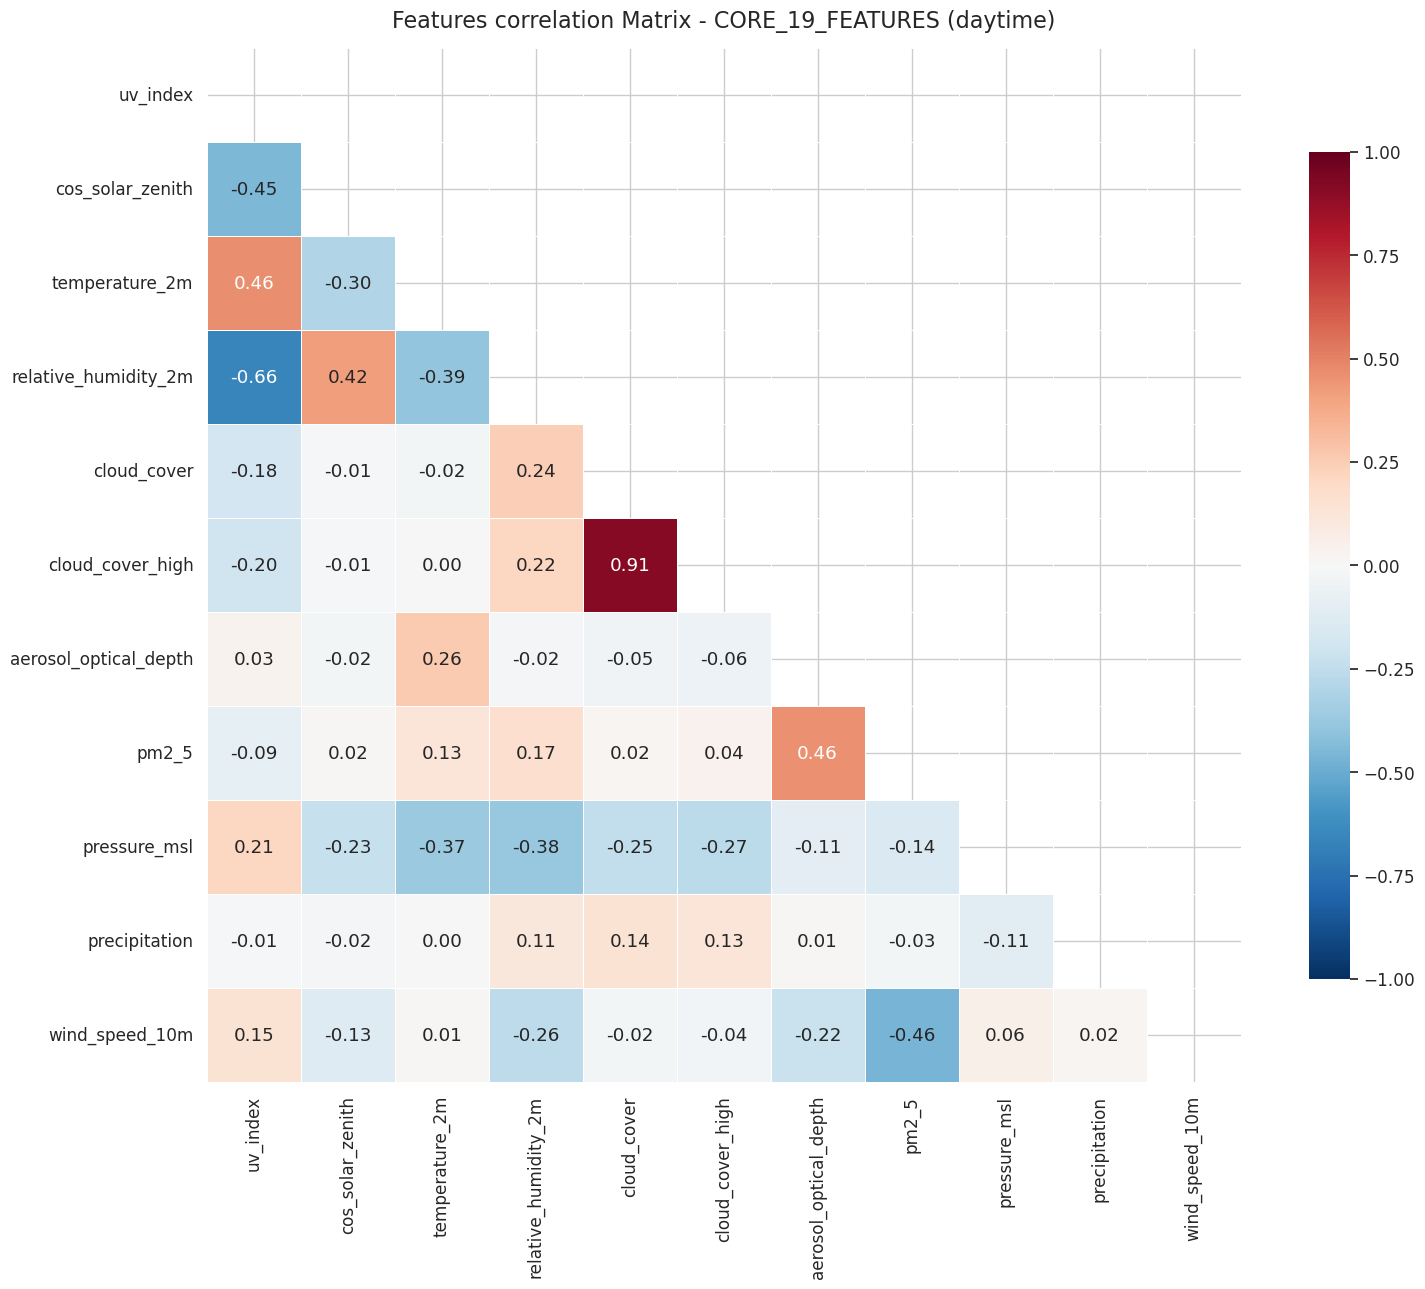

In [7]:
core_features = [
    'uv_index',
    'cos_solar_zenith', 'hour_cos', 'doy_sin',
    'temperature_2m', 'relative_humidity_2m',
    'cloud_cover', 'cloud_cover_high', 'solar_cloud_interaction',
    'ozone_anomaly', 'aerosol_optical_depth', 'pm2_5',
    'pressure_msl', 'precipitation', 'wind_speed_10m',
    'cloud_cover_change_1h', 'temp_change_3h', 'humidity_change_1h',
    'pressure_change_3h', 'solar_noon_proximity'
]

existing = [c for c in core_features if c in day.columns]
print(f"Available features: {len(existing)}/{len(core_features)}")
print(f"Missing: {set(core_features) - set(existing)}")
corr_matrix = day[existing].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Features correlation Matrix - CORE_19_FEATURES (daytime)', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

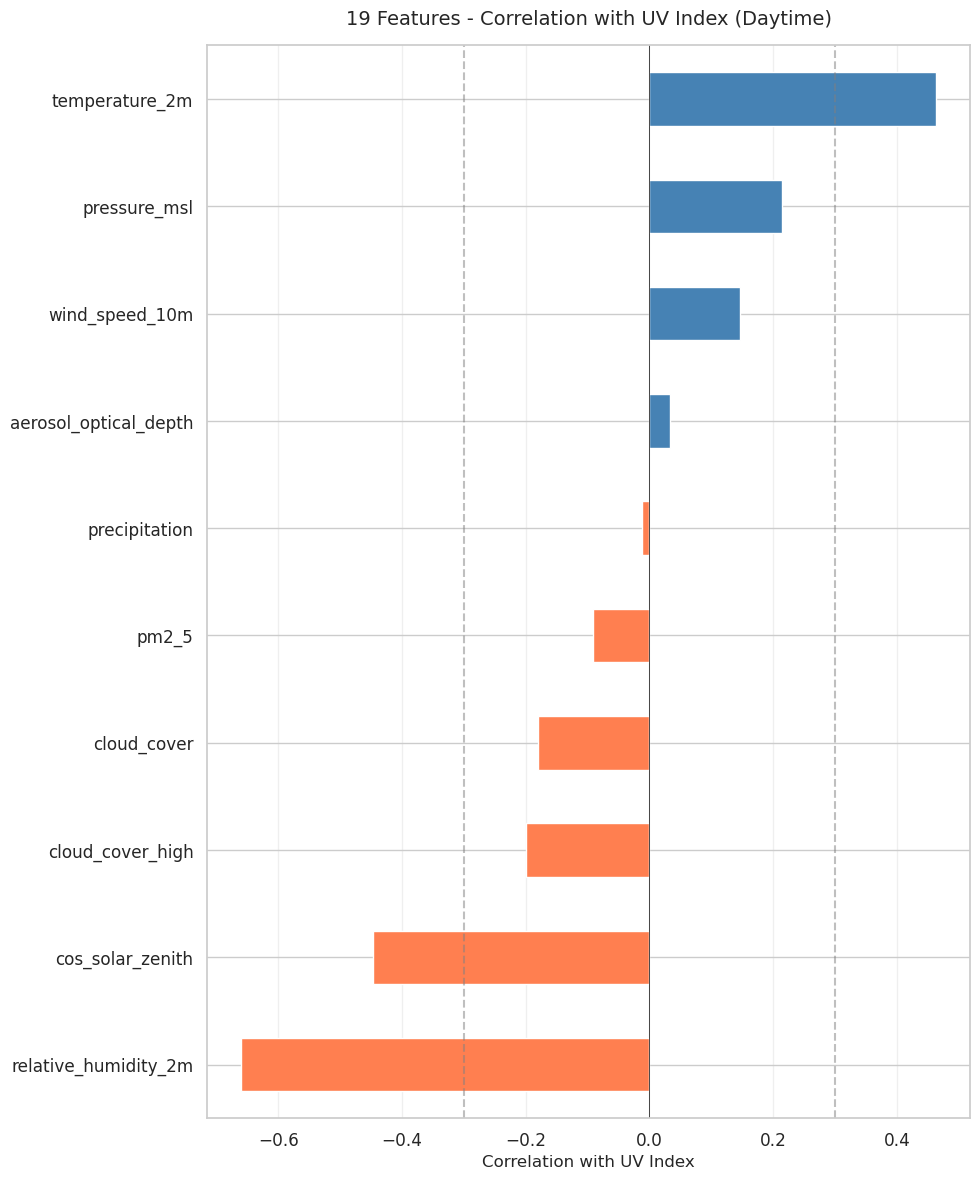


Analyzed 10 core 19 features (excludes radiation leakage

Strongest correlations:
relative_humidity_2m     0.659563
temperature_2m           0.462596
cos_solar_zenith         0.446895
pressure_msl             0.214824
cloud_cover_high         0.199632
cloud_cover              0.180665
wind_speed_10m           0.146708
pm2_5                    0.091437
aerosol_optical_depth    0.033356
precipitation            0.012049
Name: uv_index, dtype: float64


In [8]:
numeric_cols = day.select_dtypes(include=[np.number]).columns
core_numeric = [c for c in core_features if c in numeric_cols and c != 'uv_index']

uv_corr = day[core_numeric + ['uv_index']].corr()['uv_index'].drop('uv_index').sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['coral' if v < 0 else 'steelblue' for v in uv_corr]
uv_corr.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Correlation with UV Index', fontsize=12)
ax.set_title('19 Features - Correlation with UV Index (Daytime)', fontsize=14, pad=15)
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(0.3, color='gray', linestyle='--', alpha=0.5)
ax.axvline(-0.3, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAnalyzed {len(core_numeric)} core 19 features (excludes radiation leakage")
print("\nStrongest correlations:")
print(uv_corr.abs().sort_values(ascending=False).head(10))

# 5. Key Feature Distributions

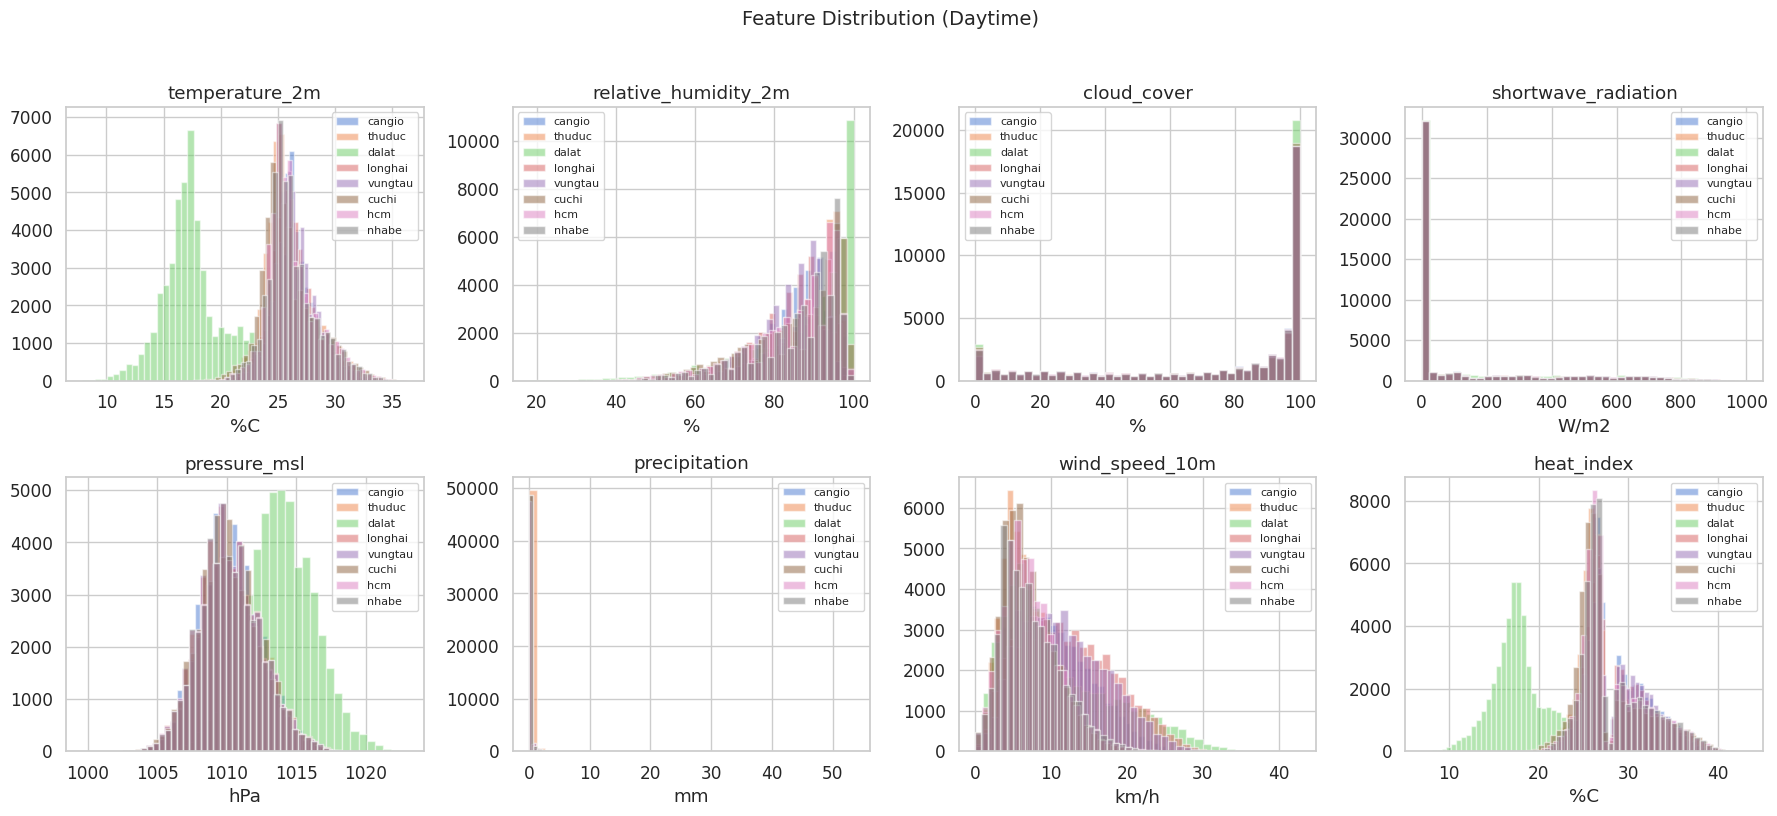

In [9]:
plot_features = [
    ('temperature_2m', '%C'), ('relative_humidity_2m', '%'),
    ('cloud_cover', '%'), ('shortwave_radiation', 'W/m2'),
    ('pressure_msl', 'hPa'), ('precipitation', 'mm'),
    ('wind_speed_10m', 'km/h'), ('heat_index', '%C')
]

plot_features = [(f, u) for f, u in plot_features if f in day.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, (feat, unit) in enumerate(plot_features):
    for loc in day['location_id'].unique():
        sub = day[day['location_id'] == loc][feat].dropna()
        axes[i].hist(sub, bins=40, alpha=0.5, label=loc, edgecolor='white')
    axes[i].set_title(feat)
    axes[i].set_xlabel(unit)
    axes[i].legend(fontsize=8)
for j in range(len(plot_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distribution (Daytime)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 6.UV vs Key features (scatter)

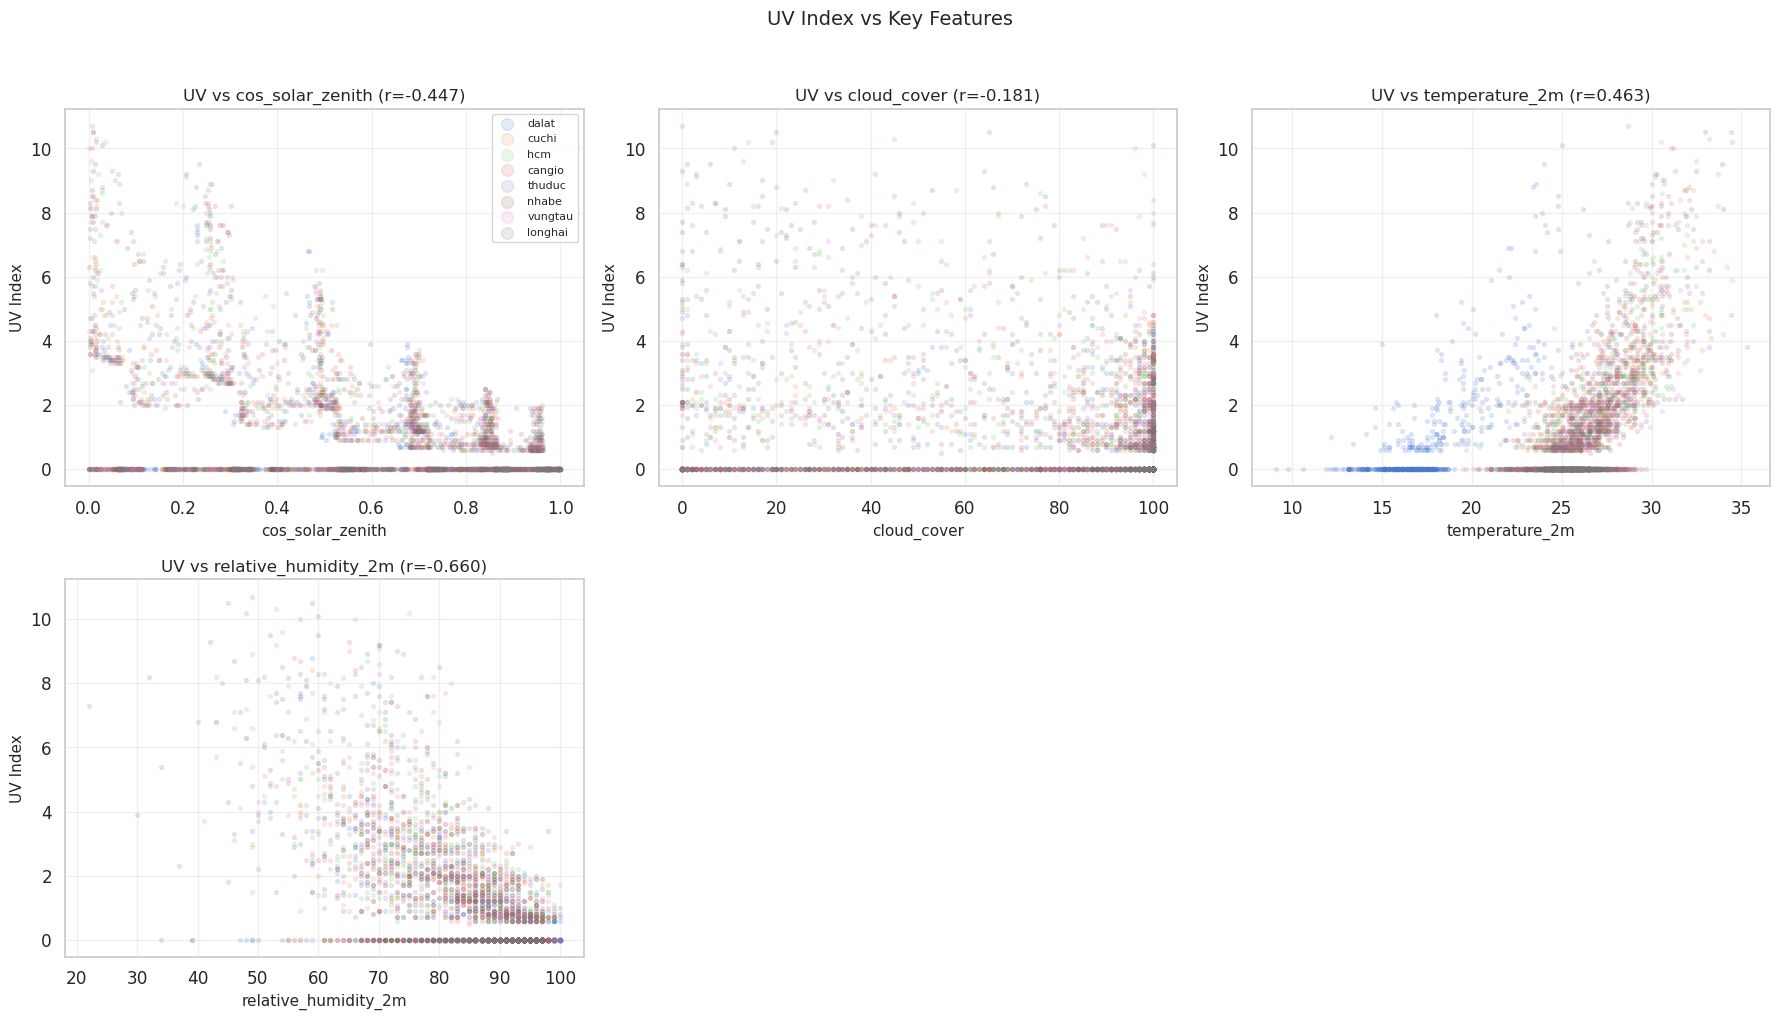

In [10]:
scatter_features = ['cos_solar_zenith', 'solar_cloud_interaction', 'cloud_cover', 'temperature_2m', 'relative_humidity_2m', 'ozone_anoemaly']

scatter_features = [f for f in scatter_features if f in day.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
sample = day.sample(min(5000, len(day)), random_state=42)

for i, feat in enumerate(scatter_features):
    for loc in sample['location_id'].unique():
        sub = sample[sample['location_id'] == loc]
        axes[i].scatter(sub[feat], sub['uv_index'], alpha=0.15, s=8, label=loc)
    corr = day[feat].corr(day['uv_index'])
    axes[i].set_xlabel(feat, fontsize=11)
    axes[i].set_ylabel('UV Index',  fontsize=11)
    axes[i].set_title(f'UV vs {feat} (r={corr:.3f})',  fontsize=12)
    if i == 0:
        axes[i].legend(fontsize=8, markerscale=3)
    axes[i].grid(alpha=0.3)

for j in range(len(scatter_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('UV Index vs Key Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 7. Time Seris - Daily UV Max

/tmp/ipykernel_6555/3853895369.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_max = day.groupby([day['timestamp'].dt.to_period('M'), 'location_id'])['uv_index'].max().unstack()


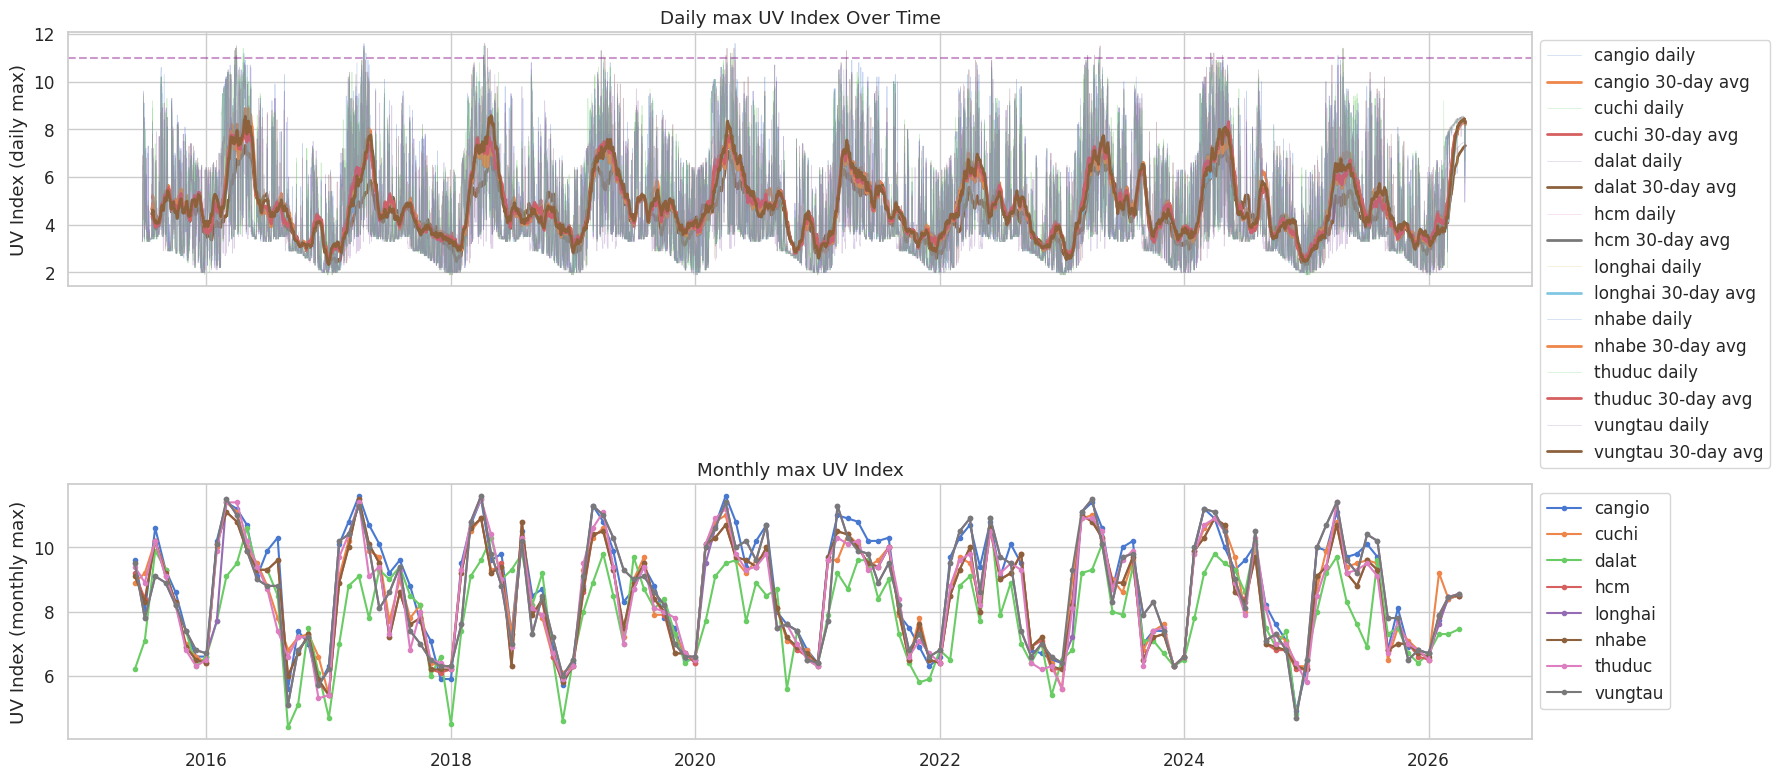

In [11]:
daily_max = day.groupby([day['timestamp'].dt.date, 'location_id'])['uv_index'].max().unstack()
daily_max.index = pd.to_datetime(daily_max.index)

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

for loc in daily_max.columns:
    axes[0].plot(daily_max.index, daily_max[loc], alpha=0.3, linewidth=0.5, label=f'{loc} daily')
    rolling = daily_max[loc].rolling(30).mean()
    axes[0].plot(daily_max.index, rolling,  linewidth=2, label=f'{loc} 30-day avg')
axes[0].set_ylabel('UV Index (daily max)')
axes[0].set_title('Daily max UV Index Over Time')
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[0].axhline(11, color='purple', linestyle='--', alpha=0.4, label='Extreme threshold')

monthly_max = day.groupby([day['timestamp'].dt.to_period('M'), 'location_id'])['uv_index'].max().unstack()
monthly_max.index = monthly_max.index.to_timestamp()
for loc in monthly_max.columns:
    axes[1].plot(monthly_max.index, monthly_max[loc], marker='o', markersize=3, linewidth=1.5, label=loc)
axes[1].set_ylabel('UV Index (monthly max)')
axes[1].set_title('Monthly max UV Index')
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# 8. Cloud Cover Impact on UV

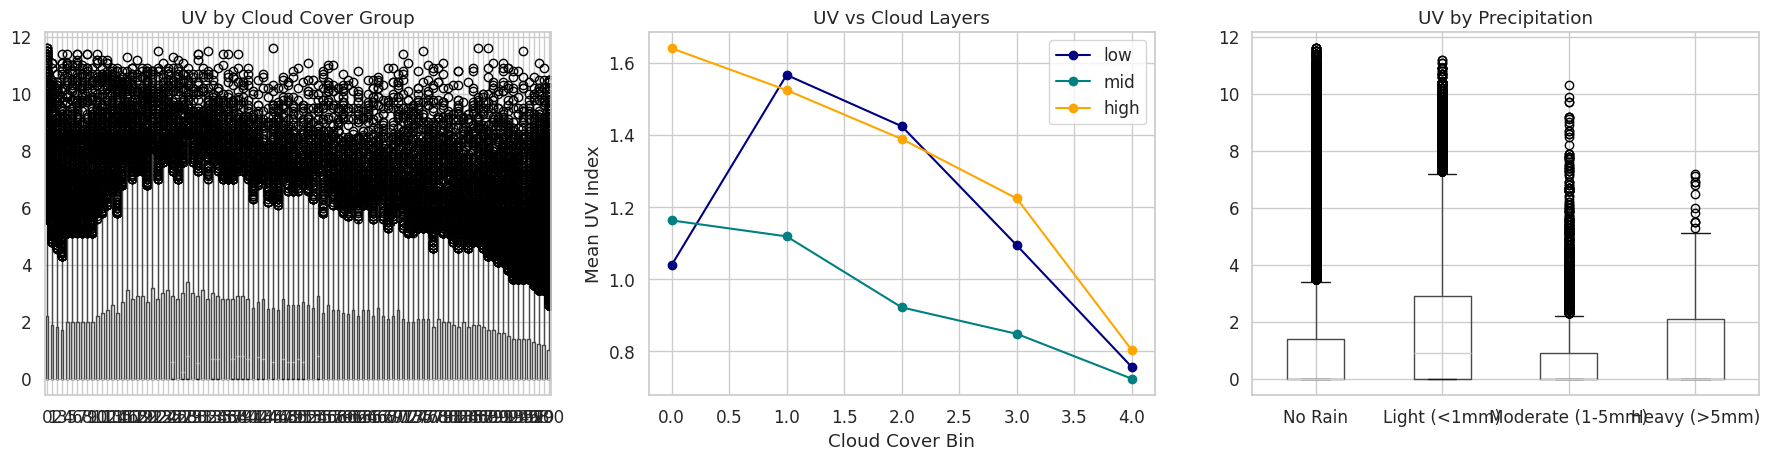

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

day['cloud_group'] = pd.cut(day['cloud_cover'], bins=[-1, 20, 60, 100],
                            labels=['Clear (0-20%)', 'Partly (20-60%)', 'Overcast (60-100%)'])
day.boxplot(column='uv_index', by='cloud_cover', ax=axes[0])
axes[0].set_title('UV by Cloud Cover Group')
axes[0].set_xlabel('')
plt.suptitle('')

for layer, color in [('cloud_cover_low', 'navy'), ('cloud_cover_mid', 'teal'), ('cloud_cover_high', 'orange')]:
    if layer in day.columns:
        binned = pd.cut(day[layer], bins=5)
        means = day.groupby(binned, observed=True)['uv_index'].mean()
        axes[1].plot(range(len(means)), means.values, marker='o', label=layer.replace('cloud_cover_', ''), color=color)

axes[1].set_xlabel('Cloud Cover Bin')
axes[1].set_ylabel('Mean UV Index')
axes[1].set_title('UV vs Cloud Layers')
axes[1].legend()

day['rain_group'] = pd.cut(day['precipitation'], bins=[-0.01, 0, 1, 5, 100],
                           labels=['No Rain', 'Light (<1mm)', 'Moderate (1-5mm)', 'Heavy (>5mm)'])
day.boxplot(column='uv_index', by='rain_group', ax=axes[2])
axes[2].set_title('UV by Precipitation')
axes[2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

# 9. Air Quality & Ozone impact

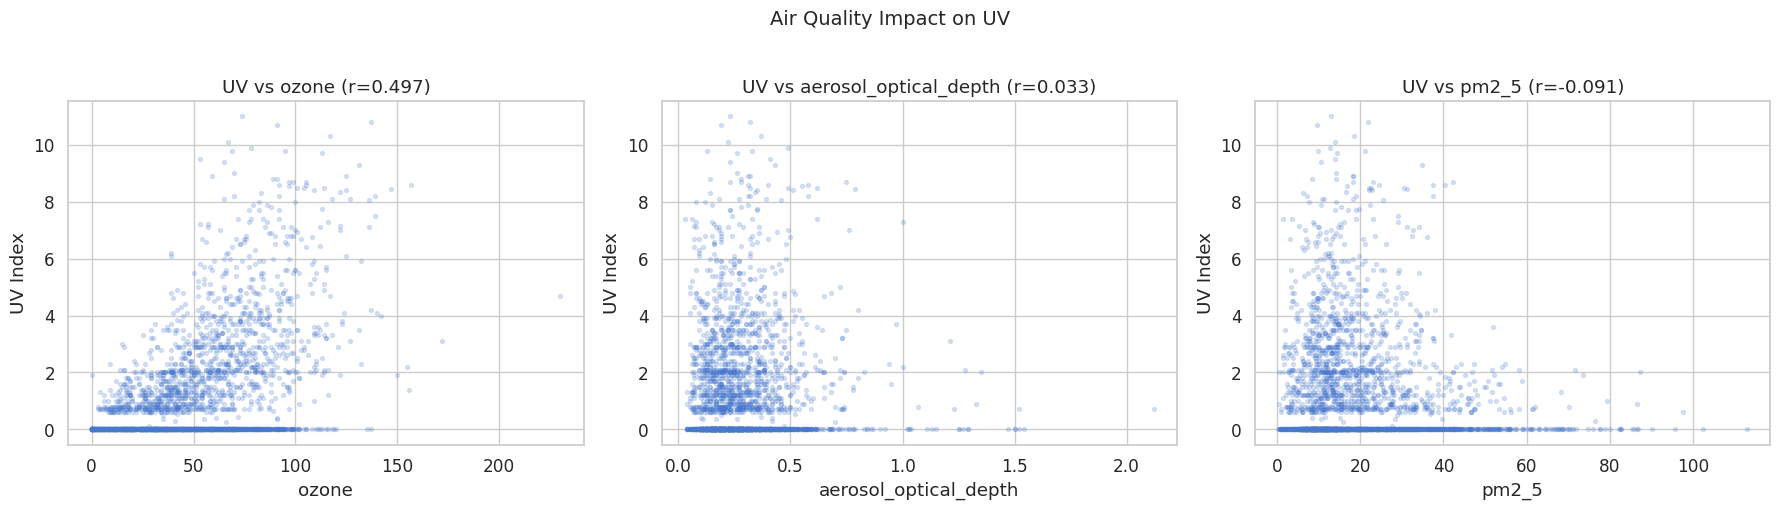

In [13]:
aq_cols = ['ozone', 'aerosol_optical_depth', 'pm2_5']
aq_present = [c for c in aq_cols if c in day.columns and day[c].notna().any()]

if aq_present:
    fig, axes = plt.subplots(1, len(aq_present), figsize=(6 * len(aq_present), 5))
    if len(aq_present) == 1:
        axes = [axes]
    sample_aq = day.dropna(subset=aq_present).sample(min(3000, len(day.dropna(subset=aq_present))), random_state=42)
    for i, col in enumerate(aq_present):
        axes[i].scatter(sample_aq[col], sample_aq['uv_index'], alpha=0.2, s=8)
        corr = day[col].corr(day['uv_index'])
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('UV Index')
        axes[i].set_title(f'UV vs {col} (r={corr:.3f})')
    plt.suptitle('Air Quality Impact on UV', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No air quality data available for plotting')

# 10 Summary Statistics

In [14]:
summary_cols = ['uv_index', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover',
                'shortwave_radiation', 'direct_radiation', 'solar_elevation',
                'precipitation', 'wind_speed_10m', 'pressure_msl', 'heat_index']

summary_cols = [c for c in summary_cols if c in day.columns]

print('=== Daytime Summary Statistics ===')
display(day[summary_cols].describe().round(2))

print('\n=== Per-Location Summary ===')
for loc in day['location_id'].unique():
    sub = day[day['location_id'] == loc]
    print(f'\n--- {loc.upper()} ({len(sub)} rows) ---')
    display(sub[summary_cols].describe().round(2))

=== Daytime Summary Statistics ===


,uv_index,temperature_2m,relative_humidity_2m,cloud_cover,shortwave_radiation,direct_radiation,solar_elevation,precipitation,wind_speed_10m,pressure_msl,heat_index
count,386992.00,404014.00,404014.00,404014.00,404014.00,404014.00,404014.00,404014.00,404014.00,404014.00,404014.00
mean,1.11,25.15,84.83,72.86,144.37,97.25,40.03,0.11,9.21,1010.68,27.03
std,1.82,3.60,11.24,33.80,241.01,181.54,23.48,0.53,5.48,2.57,5.06
min,0.00,7.90,18.00,0.00,0.00,0.00,0.00,0.00,0.00,999.60,6.96
25%,0.00,24.30,79.00,48.00,0.00,0.00,18.88,0.00,5.10,1008.90,25.07
50%,0.00,25.50,88.00,92.00,0.00,0.00,42.77,0.00,7.90,1010.40,26.51
75%,1.70,27.00,93.00,100.00,230.00,100.00,58.78,0.00,12.20,1012.30,30.31
max,11.60,36.30,100.00,100.00,1000.00,902.00,89.12,53.40,42.80,1023.00,43.14



=== Per-Location Summary ===

--- CANGIO (50623 rows) ---


,uv_index,temperature_2m,relative_humidity_2m,cloud_cover,shortwave_radiation,direct_radiation,solar_elevation,precipitation,wind_speed_10m,pressure_msl,heat_index
count,48478.00,50623.00,50623.00,50623.00,50623.00,50623.00,50623.00,50623.00,50623.00,50623.00,50623.00
mean,1.12,26.35,85.25,73.42,143.58,95.98,40.00,0.12,10.22,1010.22,28.65
std,1.87,1.91,9.52,32.97,239.70,179.86,23.55,0.52,5.07,2.23,3.55
min,0.00,17.80,39.00,0.00,0.00,0.00,0.00,0.00,0.00,1001.60,17.80
25%,0.00,25.10,80.00,49.00,0.00,0.00,18.71,0.00,6.20,1008.70,26.04
50%,0.00,26.10,88.00,92.00,0.00,0.00,43.05,0.00,9.60,1010.10,27.06
75%,1.70,27.40,93.00,100.00,230.00,95.00,58.78,0.00,13.70,1011.70,31.13
max,11.60,34.20,100.00,100.00,957.00,836.00,88.58,17.40,35.80,1019.00,41.76



--- THUDUC (50614 rows) ---


...

,uv_index,temperature_2m,relative_humidity_2m,cloud_cover,shortwave_radiation,direct_radiation,solar_elevation,precipitation,wind_speed_10m,pressure_msl,heat_index
count,48500.00,50635.00,50635.00,50635.00,50635.00,50635.00,50635.00,50635.00,50635.00,50635.00,50635.00
mean,1.12,25.86,84.78,71.97,143.86,95.48,39.91,0.11,7.01,1010.23,27.78
std,1.84,2.46,12.33,34.45,239.57,177.78,23.54,0.57,3.55,2.29,4.06
min,0.00,17.10,31.00,0.00,0.00,0.00,0.00,0.00,0.00,1001.60,16.69
25%,0.00,24.30,77.00,45.00,0.00,0.00,18.43,0.00,4.40,1008.70,25.19
50%,0.00,25.30,88.00,91.00,0.00,0.00,42.96,0.00,6.40,1010.10,26.26
75%,1.80,27.10,95.00,100.00,231.00,101.00,58.98,0.00,9.10,1011.70,30.22
max,11.40,36.30,100.00,100.00,962.00,839.00,89.12,28.40,35.60,1019.20,42.69



--- HCM (50632 rows) ---


,uv_index,temperature_2m,relative_humidity_2m,cloud_cover,shortwave_radiation,direct_radiation,solar_elevation,precipitation,wind_speed_10m,pressure_msl,heat_index
count,48498.00,50632.00,50632.00,50632.00,50632.00,50632.00,50632.00,50632.00,50632.00,50632.00,50632.00
mean,1.11,26.21,84.59,71.98,144.73,96.91,39.94,0.10,7.37,1010.21,28.30
std,1.81,2.25,11.64,34.36,240.43,179.57,23.54,0.47,3.77,2.25,3.84
min,0.00,18.00,29.00,0.00,0.00,0.00,0.00,0.00,0.00,1001.60,17.79
25%,0.00,24.80,78.00,45.00,0.00,0.00,18.56,0.00,4.70,1008.70,25.71
50%,0.00,25.80,88.00,91.00,0.00,0.00,43.00,0.00,6.80,1010.10,26.70
75%,1.74,27.30,94.00,100.00,235.00,105.00,58.91,0.00,9.50,1011.70,30.82
max,11.50,36.30,100.00,100.00,964.00,841.00,88.89,15.50,34.40,1019.10,42.82



--- NHABE (50631 rows) ---


,uv_index,temperature_2m,relative_humidity_2m,cloud_cover,shortwave_radiation,direct_radiation,solar_elevation,precipitation,wind_speed_10m,pressure_msl,heat_index
count,48497.00,50631.00,50631.00,50631.00,50631.00,50631.00,50631.00,50631.00,50631.00,50631.00,50631.00
mean,1.11,26.20,85.27,72.22,143.25,96.91,39.95,0.11,7.38,1010.22,28.32
std,1.81,2.24,11.13,34.18,238.52,179.59,23.55,0.50,3.98,2.24,3.87
min,0.00,17.60,33.00,0.00,0.00,0.00,0.00,0.00,0.00,1001.60,17.37
25%,0.00,24.80,79.00,46.00,0.00,0.00,18.57,0.00,4.30,1008.70,25.73
50%,0.00,25.80,89.00,91.00,0.00,0.00,43.03,0.00,6.60,1010.10,26.72
75%,1.80,27.20,94.00,100.00,231.00,104.50,58.90,0.00,9.80,1011.70,30.87
max,11.50,36.00,100.00,100.00,964.00,841.00,88.84,28.10,33.00,1019.10,43.14
